In [1]:
import os
import glob
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree


In [2]:

PCA_FEATURE_NAMES = [
    'pc1_var', 'pc2_var', 'pc3_var', 'elongation',
    'depth_loading', 'time_loading', 'charge_loading',
    'n_strings', 'n_doms', 'n_hits', 'total_charge',
    'log_energy', 'pc1_pc2_sum'
]


def build_geo_dict_kdtree(geo_df):
    coords = geo_df[['dom_x', 'dom_y', 'dom_z']].values.astype(float)
    kd_tree = KDTree(coords, leafsize=40)
    string_ids = geo_df['string'].values.astype(int)
    return kd_tree, string_ids


def map_pulse_to_string(x, y, z, kd_tree, string_ids, max_distance=50.0):
    distance, idx = kd_tree.query([x, y, z])
    if distance > max_distance:
        return -1
    return int(string_ids[idx])


def stream_events_with_truth(db_file, join_reco=False):
    """Yield (event_no, pulse_rows, meta_dict) per event.
    join_reco=True also pulls cascade vertex/energy from the reco table."""
    if not os.path.exists(db_file):
        raise FileNotFoundError(f"DB file not found: {db_file}")

    conn = sqlite3.connect(db_file)

    if join_reco:
        query = """
            SELECT p.event_no, p.dom_x, p.dom_y, p.dom_z, p.dom_time, p.charge,
                   r.cascade_vertex_fit_x, r.cascade_vertex_fit_y, r.cascade_vertex_fit_z,
                   r.cascade_reco_energy_tev
            FROM   CleanedROIPulses p
            JOIN   truth t ON p.event_no = t.event_no
            JOIN   reco  r ON p.event_no = r.event_no
            ORDER  BY p.event_no
        """
    else:
        query = """
            SELECT p.event_no, p.dom_x, p.dom_y, p.dom_z, p.dom_time, p.charge
            FROM   CleanedROIPulses p
            JOIN   truth t ON p.event_no = t.event_no
            ORDER  BY p.event_no
        """

    cursor = conn.cursor()
    cursor.execute(query)
    current_event = None
    buffer        = []
    current_meta  = {}

    for row in cursor:
        event_no = row[0]
        pulse    = row[:6]
        meta = {}
        if join_reco:
            meta = {
                "cascade_vertex_fit_x": row[6],
                "cascade_vertex_fit_y": row[7],
                "cascade_vertex_fit_z": row[8],
                "cascade_reco_energy_tev": row[9],
            }

        if current_event is None:
            current_event = event_no
            current_meta  = meta

        if event_no != current_event:
            yield current_event, buffer, current_meta
            buffer        = []
            current_event = event_no
            current_meta  = meta

        buffer.append(pulse)

    if buffer:
        yield current_event, buffer, current_meta

    conn.close()


def compute_pca_features(rows, kd_tree, string_ids_geo, meta=None,
                          t_scale=500.0, xyz_scale=500.0, charge_threshold=0.0):
    rows   = np.array(rows, dtype=object)
    x_hits = rows[:, 1].astype(float)
    y_hits = rows[:, 2].astype(float)
    z_hits = rows[:, 3].astype(float)
    t_hits = rows[:, 4].astype(float)
    q_hits = rows[:, 5].astype(float)

    t0   = t_hits.min()
    mask = (t_hits >= t0) & (t_hits <= t0 + 1500.0)
    x_hits, y_hits, z_hits = x_hits[mask], y_hits[mask], z_hits[mask]
    t_hits, q_hits          = t_hits[mask], q_hits[mask]
    t_hits                  = t_hits - t0

    q_mask = q_hits > charge_threshold
    x_hits, y_hits, z_hits = x_hits[q_mask], y_hits[q_mask], z_hits[q_mask]
    t_hits, q_hits          = t_hits[q_mask], q_hits[q_mask]

    string_ids = np.array([
        map_pulse_to_string(xi, yi, zi, kd_tree, string_ids_geo)
        for xi, yi, zi in zip(x_hits, y_hits, z_hits)
    ])
    valid = string_ids >= 0
    x_hits, y_hits, z_hits     = x_hits[valid], y_hits[valid], z_hits[valid]
    t_hits, q_hits, string_ids = t_hits[valid], q_hits[valid], string_ids[valid]

    if len(t_hits) < 4 or len(np.unique(string_ids)) < 2:
        return {
            'is_valid': False,
            'pc1_var': 0.0, 'pc2_var': 0.0, 'pc3_var': 1.0,
            'elongation': 1.0, 'depth_loading': 0.0, 'time_loading': 0.0,
            'charge_loading': 0.0, 'n_strings': 0.0, 'n_doms': 0.0, 'n_hits': 0.0,
            'total_charge': 0.0, 'log_energy': 0.0, 'pc1_pc2_sum': 0.0
        }

    X_spatial = np.column_stack([x_hits, y_hits, z_hits])
    charges = q_hits
    weights = charges / charges.sum()
    X_centered = X_spatial - np.average(X_spatial, weights=weights, axis=0)
    cov_weighted = np.cov(X_centered.T, aweights=weights)
    eigenvals_spatial, _ = np.linalg.eigh(cov_weighted)
    idx = np.argsort(eigenvals_spatial)[::-1]
    eigenvals_spatial = eigenvals_spatial[idx]

    total_var = eigenvals_spatial.sum() + 1e-10
    pc1_var = float(eigenvals_spatial[0] / total_var)
    pc2_var = float(eigenvals_spatial[1] / total_var)
    pc3_var = float(eigenvals_spatial[2] / total_var)
    elongation = float(eigenvals_spatial[0] / (eigenvals_spatial[2] + 1e-10))

    from sklearn.preprocessing import StandardScaler
    X_temporal = np.column_stack([t_hits, q_hits, z_hits])
    X_temporal_scaled = StandardScaler().fit_transform(X_temporal)

    cov_temporal = np.cov(X_temporal_scaled.T)
    eigenvals_temporal, eigenvecs_temporal = np.linalg.eigh(cov_temporal)
    idx_t = np.argsort(eigenvals_temporal)[::-1]
    eigenvecs_temporal = eigenvecs_temporal[:, idx_t]

    pc1_loadings = eigenvecs_temporal[:, 0]
    depth_loading = float(np.abs(pc1_loadings[2]))
    time_loading = float(np.abs(pc1_loadings[0]))
    charge_loading = float(np.abs(pc1_loadings[1]))

    cascade_reco_energy_tev = float(meta.get("cascade_reco_energy_tev", 0.05)) if meta else 0.05
    log_energy = np.log10(max(cascade_reco_energy_tev, 0.05)) / 6.0

    n_strings = len(np.unique(string_ids))
    n_doms = len(np.unique(np.column_stack([x_hits, y_hits, z_hits]), axis=0))
    n_hits = len(t_hits)
    total_charge = float(charges.sum())

    return {
        'is_valid': True,
        'pc1_var': pc1_var, 'pc2_var': pc2_var, 'pc3_var': pc3_var,
        'elongation': min(elongation, 50.0),
        'depth_loading': depth_loading, 'time_loading': time_loading,
        'charge_loading': charge_loading,
        'n_strings': float(n_strings), 'n_doms': float(n_doms), 'n_hits': float(n_hits),
        'total_charge': total_charge, 'log_energy': log_energy,
        'pc1_pc2_sum': pc1_var + pc2_var,
    }


def collect_pca_features_from_dir(db_dir, kd_tree, string_ids_geo, n_files=5,
                                   max_events_per_file=None, charge_threshold=0.1,
                                   pattern="*.db", join_reco=False):
    db_paths = sorted(glob.glob(os.path.join(db_dir, pattern)))[:n_files]
    if not db_paths:
        raise FileNotFoundError(f"No DB files matching {pattern} in {db_dir}")

    rows_out, n_total, n_invalid = [], 0, 0

    for db_path in db_paths:
        n_this_file = 0
        for eid, rows, meta in stream_events_with_truth(db_path, join_reco=join_reco):
            if max_events_per_file and n_this_file >= max_events_per_file:
                break
            n_total += 1
            n_this_file += 1

            feats = compute_pca_features(rows, kd_tree, string_ids_geo, meta=meta,
                                          charge_threshold=charge_threshold)
            if feats["is_valid"]:
                feats["event_no"] = eid
                feats["db_file"]  = os.path.basename(db_path)
                rows_out.append(feats)
            else:
                n_invalid += 1

    df = pd.DataFrame(rows_out)
    print(f"{db_dir}")
    print(f"  files loaded: {len(db_paths)}")
    print(f"  events seen:  {n_total}")
    print(f"  valid:        {len(df)} ({100 * len(df) / max(n_total, 1):.1f}%)")
    print(f"  invalid:      {n_invalid}")
    return df

In [3]:
NUTAU_DIR = "/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train"
NUE_DIR   = "/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_train"

geo = pd.read_csv("/mnt/scratch/baburish/doublepulse/gnn/Analysis/geometry_clean.csv")
kd_tree, string_ids_geo = build_geo_dict_kdtree(geo)

df_tau = collect_pca_features_from_dir(NUTAU_DIR, kd_tree, string_ids_geo, n_files=20,
                                        pattern='nutau_gemini_ftp_65TeV_*.db', join_reco=True)
df_nue = collect_pca_features_from_dir(NUE_DIR, kd_tree, string_ids_geo, n_files=20,
                                        pattern='nue_gemini_ftp_65TeV_*.db', join_reco=True)

print(f"Collected {len(df_tau)} nutau events and {len(df_nue)} nue events.")
df_tau["label"] = "nutau"
df_nue["label"] = "nue"
df_all = pd.concat([df_tau, df_nue], ignore_index=True)

/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train
  files loaded: 20
  events seen:  1785
  valid:        1707 (95.6%)
  invalid:      78
/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nue_train
  files loaded: 20
  events seen:  2523
  valid:        2412 (95.6%)
  invalid:      111
Collected 1707 nutau events and 2412 nue events.


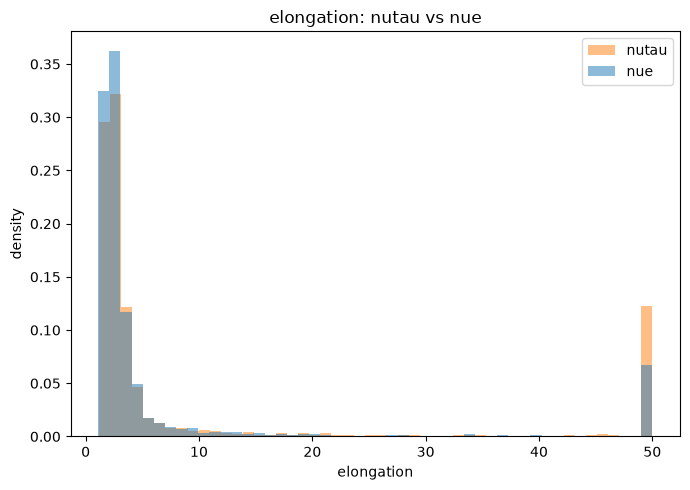

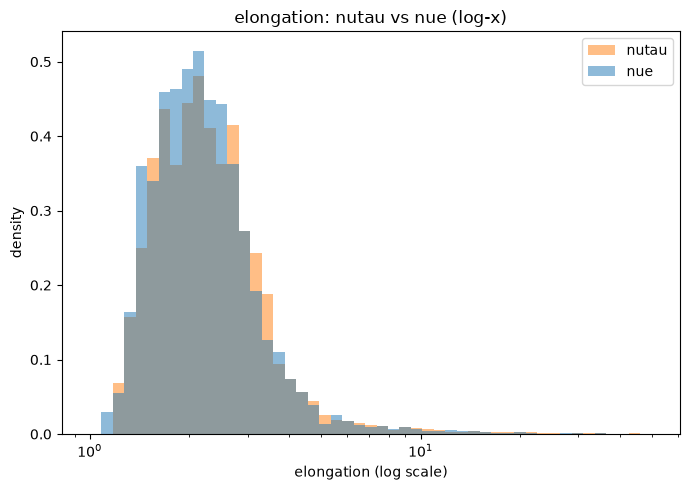

In [4]:
from sklearn.metrics import roc_auc_score
from scipy import stats

# --- basic distribution ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df_tau["elongation"], bins=50, alpha=0.5, label="nutau", density=True, color="tab:orange")
ax.hist(df_nue["elongation"], bins=50, alpha=0.5, label="nue", density=True, color="tab:blue")
ax.set_xlabel("elongation")
ax.set_ylabel("density")
ax.legend()
ax.set_title("elongation: nutau vs nue")
plt.tight_layout()
plt.show()

# same, log-x since elongation is heavily right-skewed (min=1, long tail)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df_tau["elongation"], bins=np.logspace(0, np.log10(df_all["elongation"].max()), 50),
        alpha=0.5, label="nutau", density=True, color="tab:orange")
ax.hist(df_nue["elongation"], bins=np.logspace(0, np.log10(df_all["elongation"].max()), 50),
        alpha=0.5, label="nue", density=True, color="tab:blue")
ax.set_xscale("log")
ax.set_xlabel("elongation (log scale)")
ax.set_ylabel("density")
ax.legend()
ax.set_title("elongation: nutau vs nue (log-x)")
plt.tight_layout()
plt.show()

In [6]:
print(df_all.groupby("label")["elongation"].describe())

y = (df_all["label"] == "nutau").astype(int)
auc = roc_auc_score(y, df_all["elongation"])
auc_directionless = max(auc, 1 - auc)

ks_stat, ks_pval = stats.ks_2samp(df_tau["elongation"], df_nue["elongation"])

mean_tau, mean_nue = df_tau["elongation"].mean(), df_nue["elongation"].mean()
std_tau, std_nue   = df_tau["elongation"].std(), df_nue["elongation"].std()
pooled_std = np.sqrt((std_tau**2 + std_nue**2) / 2)
cohens_d = (mean_tau - mean_nue) / pooled_std

print(f"\nAUC (single-feature): {auc_directionless:.4f}")
print(f"KS stat: {ks_stat:.4f}   p-value: {ks_pval:.4g}")
print(f"Cohen's d: {cohens_d:.4f}")

        count      mean        std       min       25%       50%       75%  \
label                                                                        
nue    2412.0  6.630050  12.282618  1.116288  1.956946  2.516112  3.616576   
nutau  1707.0  9.722217  15.937074  1.180300  2.061246  2.752655  4.637982   

        max  
label        
nue    50.0  
nutau  50.0  

AUC (single-feature): 0.5555
KS stat: 0.0930   p-value: 5.599e-08
Cohen's d: 0.2173


In [7]:
def stratified_auc(df, feature, size_col="n_hits", q=4):
    df = df.copy()
    df["_bin"] = pd.qcut(df[size_col], q=q, duplicates="drop")
    rows = []
    for bin_name, group in df.groupby("_bin"):
        n_tau = (group["label"] == "nutau").sum()
        n_nue = (group["label"] == "nue").sum()
        if n_tau < 5 or n_nue < 5:
            continue
        y_bin = (group["label"] == "nutau").astype(int)
        auc_bin = roc_auc_score(y_bin, group[feature])
        rows.append({"bin": str(bin_name), "n_tau": n_tau, "n_nue": n_nue,
                      "auc": max(auc_bin, 1 - auc_bin)})
    return pd.DataFrame(rows)

print(stratified_auc(df_all, "elongation").to_string(index=False))

              bin  n_tau  n_nue      auc
   (3.999, 671.5]    493    537 0.576896
  (671.5, 1528.0]    436    596 0.513431
 (1528.0, 1984.5]    391    636 0.517050
(1984.5, 15249.0]    387    643 0.546023


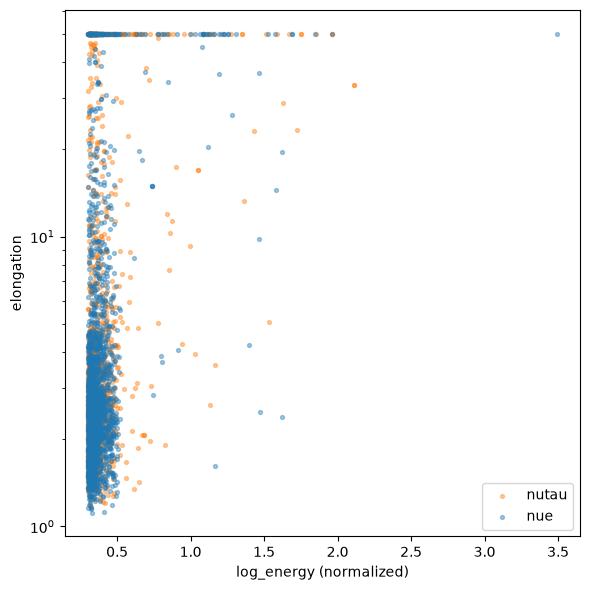

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_tau["log_energy"], df_tau["elongation"], s=8, alpha=0.4, label="nutau", color="tab:orange")
ax.scatter(df_nue["log_energy"], df_nue["elongation"], s=8, alpha=0.4, label="nue", color="tab:blue")
ax.set_xlabel("log_energy (normalized)")
ax.set_ylabel("elongation")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
n_clipped_tau = (df_tau["elongation"] >= 49.99).sum()
n_clipped_nue = (df_nue["elongation"] >= 49.99).sum()
print(f"tau clipped: {n_clipped_tau} / {len(df_tau)} ({100*n_clipped_tau/len(df_tau):.2f}%)")
print(f"nue clipped: {n_clipped_nue} / {len(df_nue)} ({100*n_clipped_nue/len(df_nue):.2f}%)")

tau clipped: 205 / 1707 (12.01%)
nue clipped: 157 / 2412 (6.51%)


In [16]:
from sklearn.preprocessing import StandardScaler
def get_raw_event(db_path, target_event_no):
    for e, rows, meta in stream_events_with_truth(db_path):
        if e == target_event_no:
            return np.array(rows, dtype=object), meta
    raise ValueError(f"event_no={target_event_no} not found in {db_path}")


# pick any real event_no to inspect -- e.g. the first one with a reasonable hit count
def first_event_with_min_hits(db_path, min_hits=20):
    for e, rows, meta in stream_events_with_truth(db_path):
        if len(rows) >= min_hits:
            return e
    return None



def get_temporal_pca_for_event(db_path, target_event_no, kd_tree, string_ids_geo,
                                 charge_threshold=0.1):
    """Recompute the per-hit (t, q, z) PCA for one event, and return everything
    needed to visualize it: the standardized points, the PC1 vector, and loadings."""
    rows_raw, meta = get_raw_event(db_path, target_event_no)

    x_hits = rows_raw[:, 1].astype(float)
    y_hits = rows_raw[:, 2].astype(float)
    z_hits = rows_raw[:, 3].astype(float)
    t_hits = rows_raw[:, 4].astype(float)
    q_hits = rows_raw[:, 5].astype(float)

    t0 = t_hits.min()
    mask = (t_hits >= t0) & (t_hits <= t0 + 1500.0)
    x_hits, y_hits, z_hits = x_hits[mask], y_hits[mask], z_hits[mask]
    t_hits, q_hits = t_hits[mask], q_hits[mask]
    t_hits = t_hits - t0

    q_mask = q_hits > charge_threshold
    x_hits, y_hits, z_hits = x_hits[q_mask], y_hits[q_mask], z_hits[q_mask]
    t_hits, q_hits = t_hits[q_mask], q_hits[q_mask]

    X_temporal = np.column_stack([t_hits, q_hits, z_hits])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_temporal)

    cov = np.cov(X_scaled.T)
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigenvals)[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]

    pc1 = eigenvecs[:, 0]
    time_loading, charge_loading, depth_loading = np.abs(pc1[0]), np.abs(pc1[1]), np.abs(pc1[2])

    return {
        "X_scaled": X_scaled,        # standardized (t, q, z) per hit
        "pc1_vector": pc1,           # unit vector in (t, q, z) space
        "eigenvals": eigenvals,
        "time_loading": time_loading,
        "charge_loading": charge_loading,
        "depth_loading": depth_loading,
        "n_hits": len(t_hits),
    }


tau_db_paths = sorted(glob.glob(os.path.join(NUTAU_DIR, "nutau_gemini_ftp_65TeV_*.db")))
nutau_db = tau_db_paths[0]
print(nutau_db)
nutau_db = tau_db_paths[0]
print(nutau_db)
eid = first_event_with_min_hits(nutau_db, min_hits=20)
print(f"using event_no={eid}")
result = get_temporal_pca_for_event(nutau_db, eid, kd_tree, string_ids_geo)
print(f"n_hits={result['n_hits']}")
print(f"PC1 vector (t, q, z): {result['pc1_vector']}")
print(f"time_loading={result['time_loading']:.3f}  "
      f"charge_loading={result['charge_loading']:.3f}  "
      f"depth_loading={result['depth_loading']:.3f}")

/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train/nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022633.000945_0000.db_train.db
/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train/nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022633.000945_0000.db_train.db
using event_no=0
n_hits=3663
PC1 vector (t, q, z): [ 0.72278589 -0.18148263 -0.66681678]
time_loading=0.723  charge_loading=0.181  depth_loading=0.667


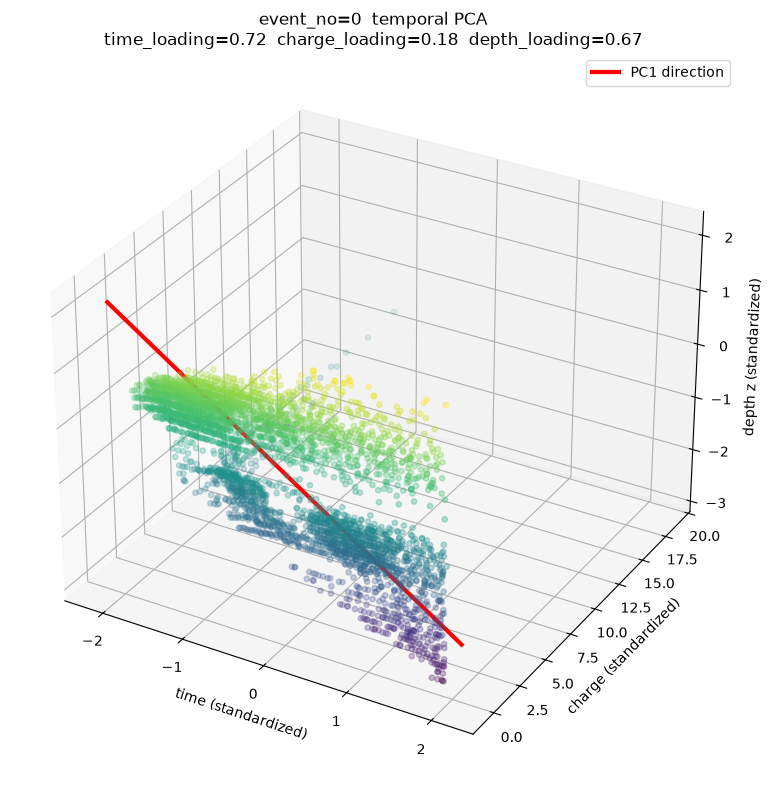

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

X_scaled = result["X_scaled"]
pc1 = result["pc1_vector"]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
           c=X_scaled[:, 2], cmap="viridis", s=15, alpha=0.6)

# draw PC1 direction as a double-headed arrow through the origin (data is mean-centered by StandardScaler)
scale = 3.0  # arrow length, in standardized units
ax.plot([-scale*pc1[0], scale*pc1[0]],
         [-scale*pc1[1], scale*pc1[1]],
         [-scale*pc1[2], scale*pc1[2]],
         color="red", lw=3, label="PC1 direction")

ax.set_xlabel("time (standardized)")
ax.set_ylabel("charge (standardized)")
ax.set_zlabel("depth z (standardized)")
ax.set_title(f"event_no={eid}  temporal PCA\n"
             f"time_loading={result['time_loading']:.2f}  "
             f"charge_loading={result['charge_loading']:.2f}  "
             f"depth_loading={result['depth_loading']:.2f}")
ax.legend()
plt.tight_layout()
plt.show()

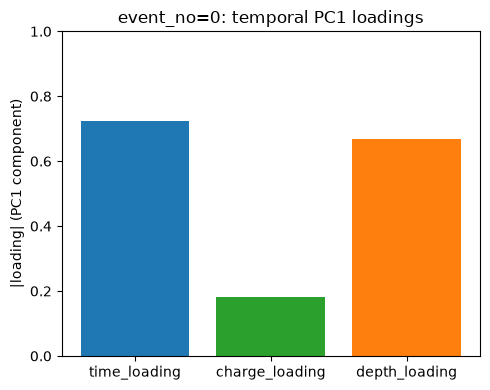

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["time_loading", "charge_loading", "depth_loading"]
values = [result["time_loading"], result["charge_loading"], result["depth_loading"]]
ax.bar(labels, values, color=["tab:blue", "tab:green", "tab:orange"])
ax.set_ylabel("|loading| (PC1 component)")
ax.set_ylim(0, 1)
ax.set_title(f"event_no={eid}: temporal PC1 loadings")
plt.tight_layout()
plt.show()

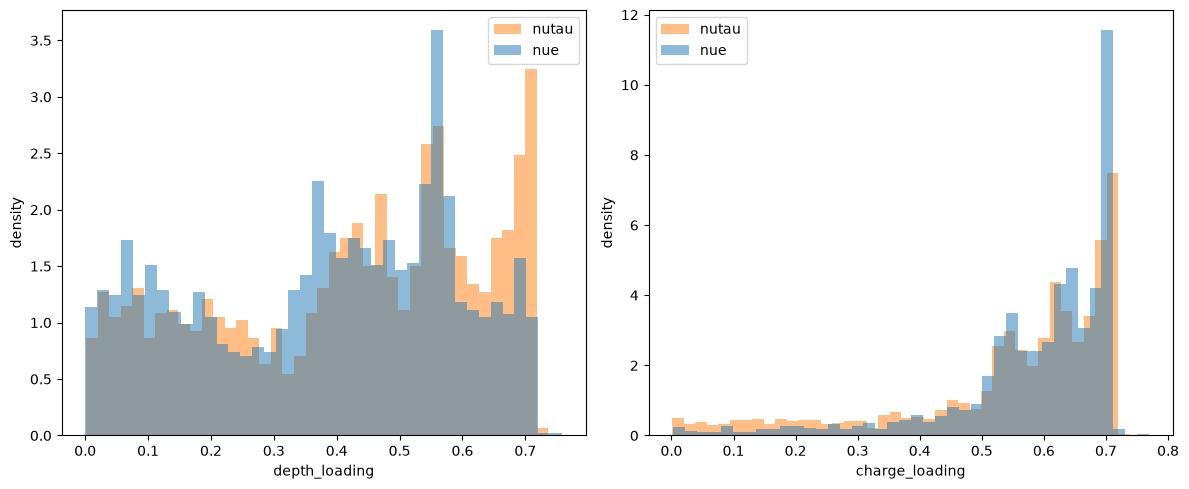

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feat in zip(axes, ["depth_loading", "charge_loading"]):
    ax.hist(df_tau[feat], bins=40, alpha=0.5, label="nutau", density=True, color="tab:orange")
    ax.hist(df_nue[feat], bins=40, alpha=0.5, label="nue", density=True, color="tab:blue")
    ax.set_xlabel(feat)
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()

In [22]:
def compare_depth_loading_vs_zspread(db_path, kd_tree, string_ids_geo, n_events=100, charge_threshold=0.1):
    rows_out = []
    n_seen = 0

    for eid_i, rows, meta in stream_events_with_truth(db_path):
        if n_seen >= n_events:
            break
        n_seen += 1

        rows_arr = np.array(rows, dtype=object)
        x_hits = rows_arr[:, 1].astype(float)
        y_hits = rows_arr[:, 2].astype(float)
        z_hits = rows_arr[:, 3].astype(float)
        t_hits = rows_arr[:, 4].astype(float)
        q_hits = rows_arr[:, 5].astype(float)

        t0 = t_hits.min()
        mask = (t_hits >= t0) & (t_hits <= t0 + 1500.0)
        x_hits, y_hits, z_hits = x_hits[mask], y_hits[mask], z_hits[mask]
        t_hits, q_hits = t_hits[mask], q_hits[mask]
        t_hits = t_hits - t0

        q_mask = q_hits > charge_threshold
        z_hits_f, q_hits_f = z_hits[q_mask], q_hits[q_mask]

        if len(z_hits_f) < 4:
            continue

        feats = compute_pca_features(rows, kd_tree, string_ids_geo, meta=meta,
                                      charge_threshold=charge_threshold)
        if not feats["is_valid"]:
            continue

        z_spread_raw = np.ptp(z_hits_f)

        rows_out.append({
            "event_no": eid_i,
            "depth_loading": feats["depth_loading"],
            "charge_loading": feats["charge_loading"],
            "time_loading": feats["time_loading"],
            "z_spread_raw": z_spread_raw,
            "n_hits": len(z_hits_f),
        })

    return pd.DataFrame(rows_out)


df_check = compare_depth_loading_vs_zspread(nutau_db, kd_tree, string_ids_geo, n_events=300)
print(f"collected {len(df_check)} events")
print(df_check[["depth_loading", "z_spread_raw"]].corr())

collected 16 events
               depth_loading  z_spread_raw
depth_loading       1.000000      0.032225
z_spread_raw        0.032225      1.000000


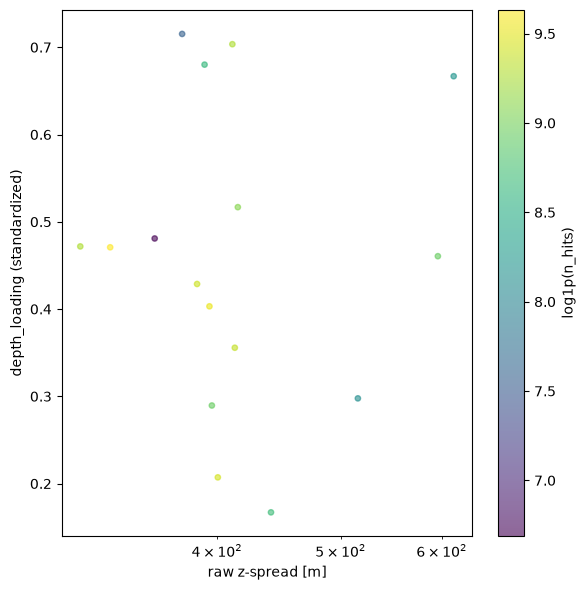

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df_check["z_spread_raw"], df_check["depth_loading"],
                 c=np.log1p(df_check["n_hits"]), cmap="viridis", s=15, alpha=0.6)
fig.colorbar(sc, ax=ax, label="log1p(n_hits)")
ax.set_xlabel("raw z-spread [m]")
ax.set_ylabel("depth_loading (standardized)")
ax.set_xscale("log")
plt.tight_layout()
plt.show()

In [24]:
def compare_depth_loading_vs_zspread_multi(db_paths, kd_tree, string_ids_geo,
                                             n_events_total=300, charge_threshold=0.1):
    all_dfs = []
    n_collected = 0
    for p in db_paths:
        if n_collected >= n_events_total:
            break
        df_p = compare_depth_loading_vs_zspread(p, kd_tree, string_ids_geo,
                                                   n_events=n_events_total - n_collected,
                                                   charge_threshold=charge_threshold)
        all_dfs.append(df_p)
        n_collected += len(df_p)
    return pd.concat(all_dfs, ignore_index=True)


df_check = compare_depth_loading_vs_zspread_multi(tau_db_paths[:20], kd_tree, string_ids_geo,
                                                    n_events_total=500)
print(f"collected {len(df_check)} events")
print(df_check[["depth_loading", "z_spread_raw"]].corr())

collected 500 events
               depth_loading  z_spread_raw
depth_loading       1.000000      0.115526
z_spread_raw        0.115526      1.000000


In [25]:
# does depth_loading correlate with n_hits, total_charge, or z_spread differently?
check_cols = ["depth_loading", "charge_loading", "time_loading", "z_spread_raw", "n_hits"]
df_check_full = df_check.copy()  # already has these except charge/total -- extend if needed
print(df_check_full[["depth_loading", "charge_loading", "time_loading", "z_spread_raw", "n_hits"]].corr())

                depth_loading  charge_loading  time_loading  z_spread_raw  \
depth_loading        1.000000       -0.843562     -0.144971      0.115526   
charge_loading      -0.843562        1.000000     -0.337769     -0.278064   
time_loading        -0.144971       -0.337769      1.000000      0.314941   
z_spread_raw         0.115526       -0.278064      0.314941      1.000000   
n_hits              -0.432786        0.449707     -0.060243      0.064243   

                  n_hits  
depth_loading  -0.432786  
charge_loading  0.449707  
time_loading   -0.060243  
z_spread_raw    0.064243  
n_hits          1.000000  


In [26]:
def compute_zspread_feature(rows, charge_threshold=0.1):
    rows_arr = np.array(rows, dtype=object)
    z_hits = rows_arr[:, 3].astype(float)
    t_hits = rows_arr[:, 4].astype(float)
    q_hits = rows_arr[:, 5].astype(float)

    t0 = t_hits.min()
    mask = (t_hits >= t0) & (t_hits <= t0 + 1500.0)
    z_hits, q_hits = z_hits[mask], q_hits[mask]

    q_mask = q_hits > charge_threshold
    z_hits, q_hits = z_hits[q_mask], q_hits[q_mask]

    if len(z_hits) < 2:
        return np.nan

    return float(np.ptp(z_hits))  # or: charge-weighted std of z, for a smoother version


def collect_zspread_feature(db_paths, n_events_per_file=None, charge_threshold=0.1):
    rows_out = []
    for p in db_paths:
        n_this = 0
        for eid_i, rows, meta in stream_events_with_truth(p):
            if n_events_per_file and n_this >= n_events_per_file:
                break
            n_this += 1
            z_spread = compute_zspread_feature(rows, charge_threshold=charge_threshold)
            if not np.isnan(z_spread):
                rows_out.append({"event_no": eid_i, "z_spread_raw": z_spread, "db_file": os.path.basename(p)})
    return pd.DataFrame(rows_out)


df_zspread_tau = collect_zspread_feature(tau_db_paths[:20])
df_zspread_nue = collect_zspread_feature(sorted(glob.glob(os.path.join(NUE_DIR, "nue_gemini_ftp_65TeV_*.db")))[:20])

df_zspread_tau["label"] = "nutau"
df_zspread_nue["label"] = "nue"
df_zspread_all = pd.concat([df_zspread_tau, df_zspread_nue], ignore_index=True)

y = (df_zspread_all["label"] == "nutau").astype(int)
auc_zspread = roc_auc_score(y, df_zspread_all["z_spread_raw"])
print(f"raw z-spread AUC: {max(auc_zspread, 1-auc_zspread):.4f}")


raw z-spread AUC: 0.5020


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = df_all[PCA_FEATURE_NAMES].values
y = (df_all["label"] == "nutau").astype(int).values

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")
print(f"5-fold CV AUC (all 13 features, scaled): {scores.mean():.4f} ± {scores.std():.4f}")

5-fold CV AUC (all 13 features, scaled): 0.5146 ± 0.0184


In [29]:
from sklearn.ensemble import GradientBoostingClassifier

clf_gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
scores_gb = cross_val_score(clf_gb, X, y, cv=5, scoring="roc_auc")
print(f"5-fold CV AUC (all 13 features, gradient boosting): {scores_gb.mean():.4f} ± {scores_gb.std():.4f}")

5-fold CV AUC (all 13 features, gradient boosting): 0.5115 ± 0.0221
